In [1]:
from experiment_common_code import ExperimentResult, plot_metrics_by_group, plot_confusion_matrix, get_list_of_plots, ExperimentResult
from common_constants import LANGUAGES, MODEL_NAMES
from icecream import ic

import torch as t

from typing import Literal

device: Literal["cuda", "cpu"] = "cuda" if t.cuda.is_available() else "cpu"

# Experiment 1

In [2]:
from experiment_1 import run_experiment_1

model_names: list[str] = MODEL_NAMES
languages: list[str] = LANGUAGES
probe_type: str = "lr"
num_layers: int | None = None

custom = False
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    probe_type = "lr"
    print(f"Using custom configuration")

ic(custom, model_names, languages, probe_type)

ic| custom: False
    model_names: ['olmo_model', 'tiny_aya_global']
    languages: ['en', 'es']
    probe_type: 'lr'


(False, ['olmo_model', 'tiny_aya_global'], ['en', 'es'], 'lr')

In [6]:
limited_layers = False
if limited_layers:
    num_layers = 3

force_probe_creation: bool = False

save_results: bool = True

ic(limited_layers, force_probe_creation, save_results)

run_experiment_1(languages, "standard", "control", probe_type, model_names, force_probe_creation, num_layers=num_layers, save_results=save_results)

Running experiment 1 instance. en, control, lr, olmo_model
Model not loaded. Getting the number of layers from ./data/activations/olmo_model/n_layers.txt
Probing at layer 0
Creating probe
Probe saved to probes\olmo_model\lr_en_layer0_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([0, 0, 0,  ..., 0, 1, 2])
Probing at layer 1
Creating probe
Probe saved to probes\olmo_model\lr_en_layer1_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([0, 0, 0,  ..., 2, 1, 0])
Probing at layer 2
Creating probe
Probe saved to probes\olmo_model\lr_en_layer2_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([0, 2, 0,  ..., 2, 2, 0])
Probing at layer 3
Creating probe
Probe saved to pr

Common attributes={'probe_type': 'lr', 'model_name': 'olmo_model', 'split': 'test', 'metric': 'accuracy'}
Varying attributes={'probing_task', 'language'}
Common attributes={'probe_type': 'lr', 'model_name': 'olmo_model', 'split': 'train', 'metric': 'accuracy'}
Varying attributes={'probing_task', 'language'}
Common attributes={'probe_type': 'lr', 'model_name': 'tiny_aya_global', 'split': 'test', 'metric': 'accuracy'}
Varying attributes={'probing_task', 'language'}
Common attributes={'probe_type': 'lr', 'model_name': 'tiny_aya_global', 'split': 'train', 'metric': 'accuracy'}
Varying attributes={'probing_task', 'language'}


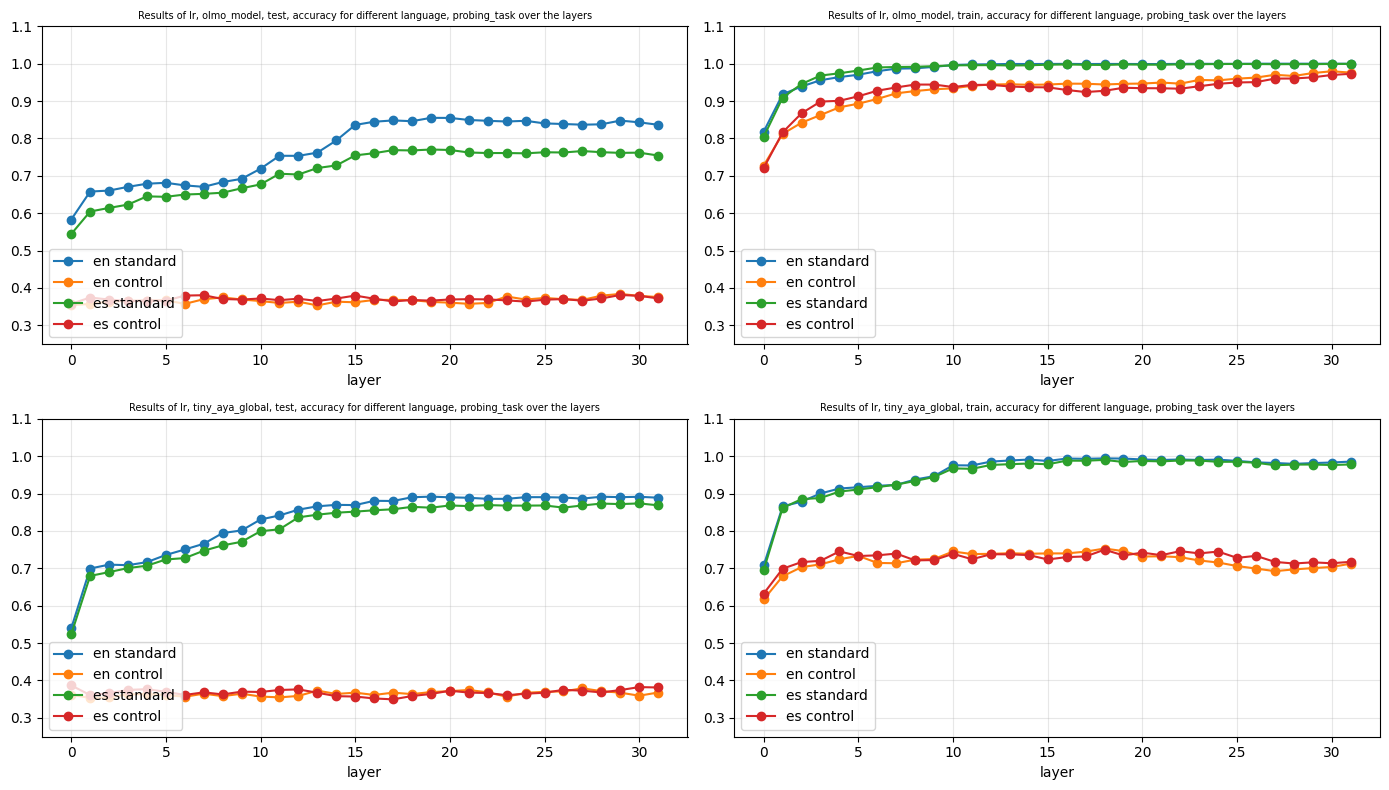

In [3]:
# Get list of plots showing accuracy
plots_to_make = get_list_of_plots(model_names, ["test", "train"], languages, ["standard", "control"], probe_type, 1, "accuracy")

# Make some plots
plot_metrics_by_group(plots_to_make, "layer", show=True)

Common attributes={'probing_task': 'standard', 'probe_type': 'lr', 'model_name': 'olmo_model', 'split': 'test', 'metric': 'marginal_accuracy'}
Varying attributes={'language'}
Common attributes={'probing_task': 'standard', 'probe_type': 'lr', 'model_name': 'olmo_model', 'split': 'train', 'metric': 'marginal_accuracy'}
Varying attributes={'language'}
Common attributes={'probing_task': 'standard', 'probe_type': 'lr', 'model_name': 'tiny_aya_global', 'split': 'test', 'metric': 'marginal_accuracy'}
Varying attributes={'language'}
Common attributes={'probing_task': 'standard', 'probe_type': 'lr', 'model_name': 'tiny_aya_global', 'split': 'train', 'metric': 'marginal_accuracy'}
Varying attributes={'language'}


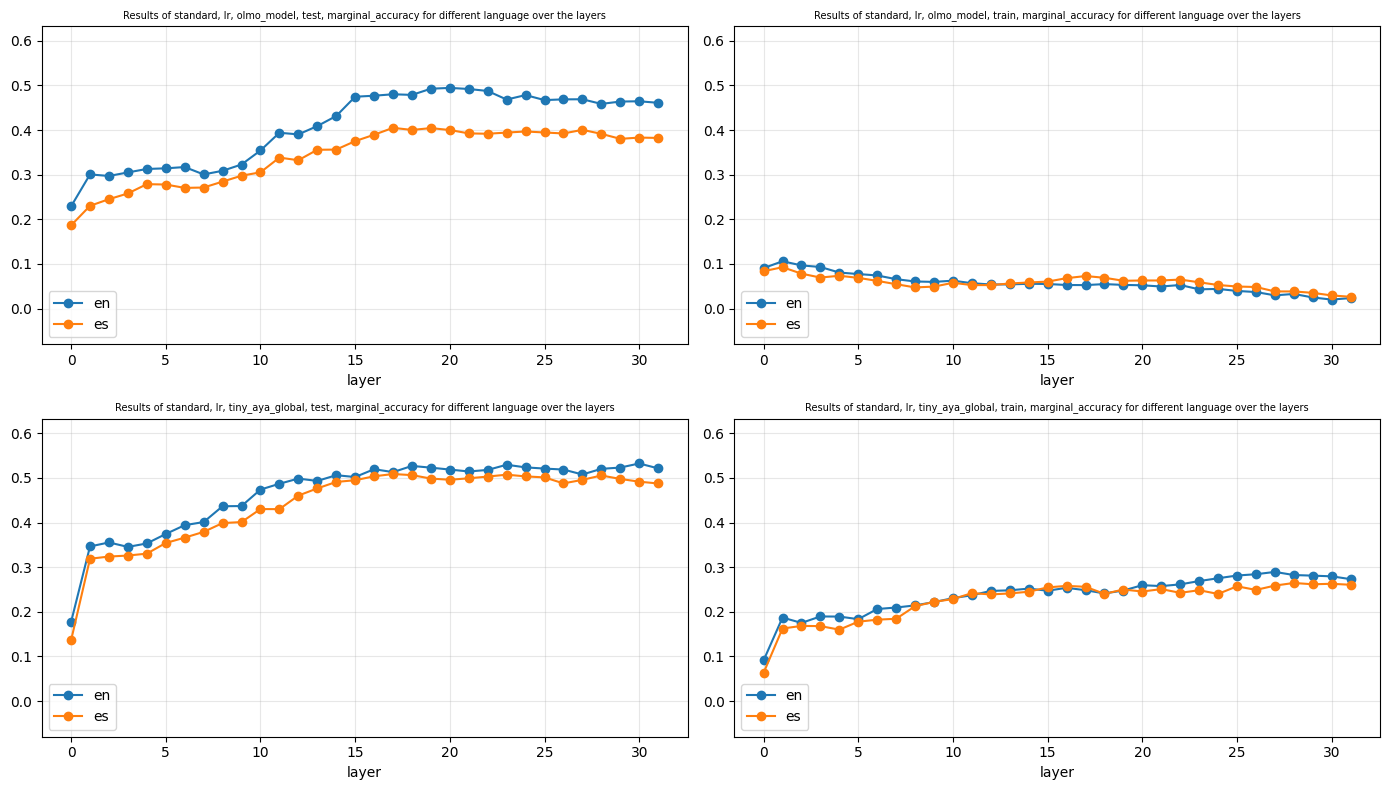

In [4]:
# Get list of plots showing marginal accuracy
plots_to_make = get_list_of_plots(model_names, ["test", "train"], languages, ["standard"], probe_type, 1, "marginal_accuracy")

# Make some plots
plot_metrics_by_group(plots_to_make, "layer", show=True)

In [ ]:
# for model_name in model_names:
#     for split in ["test", "train"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     1, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(1, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)

# Experiment 2

In [ ]:
from experiment_2 import run_experiment_2, get_multiple_language_merged_strings, get_language_pairs

model_names: list[str] = MODEL_NAMES
language_pairs: list[tuple[str, str]] = get_language_pairs(LANGUAGES)
probe_type: str = "lr"

language_pairs_as_strings: list[str] = get_multiple_language_merged_strings(language_pairs)

custom = False
if custom:
    model_names = ["olmo_model"]
    languages = ["en"]
    probe_type = "lr"
    print(f"Using custom configuration")

ic(custom, model_names, language_pairs, language_pairs_as_strings, probe_type)

ic| custom: False
    model_names: ['olmo_model', 'tiny_aya_global']
    language_pairs: [('en', 'es'), ('es', 'en')]
    probe_type: 'lr'


(False, ['olmo_model', 'tiny_aya_global'], [('en', 'es'), ('es', 'en')], 'lr')

In [ ]:
num_layers: int | None = None

limited_layers = False
if limited_layers:
    num_layers = 3

force_probe_creation: bool = False

save_results: bool = True

ic(limited_layers, num_layers, force_probe_creation, save_results)

run_experiment_2(language_pairs, "standard", "control", probe_type, model_names, force_probe_creation, num_layers=num_layers, save_results=save_results)

ic| limited_layers: False
    num_layers: None
    force_probe_creation: False
    save_results: True


Running experiment 2 instance. en→es, control, lr, olmo_model
Model not loaded. Getting the number of layers from ./data/activations/olmo_model/n_layers.txt
Probing at layer 0
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer0_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([2, 2, 2,  ..., 2, 1, 2])
Probing at layer 1
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer1_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([1, 1, 1,  ..., 1, 2, 1])
Probing at layer 2
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer2_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few t

c:\Users\nicol\PycharmProjects\bachelor_thesis\experiment_common_code.py:87: RuntimeWarning: invalid value encountered in scalar divide
  precision: float = float(cm[class_idx, class_idx] / np.sum(cm[:, class_idx]))


Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer9_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([1, 1, 1,  ..., 1, 1, 1])
Probing at layer 10
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer10_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([1, 1, 1,  ..., 1, 0, 1])
Probing at layer 11
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer11_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([1, 1, 1,  ..., 1, 2, 2])
Probing at layer 12
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer12_control.pt
Fir

c:\Users\nicol\PycharmProjects\bachelor_thesis\experiment_common_code.py:87: RuntimeWarning: invalid value encountered in scalar divide
  precision: float = float(cm[class_idx, class_idx] / np.sum(cm[:, class_idx]))


...

Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer27_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([0, 0, 0,  ..., 0, 0, 0])
Probing at layer 28


c:\Users\nicol\PycharmProjects\bachelor_thesis\experiment_common_code.py:87: RuntimeWarning: invalid value encountered in scalar divide
  precision: float = float(cm[class_idx, class_idx] / np.sum(cm[:, class_idx]))


Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer28_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([0, 0, 0,  ..., 0, 0, 0])
Probing at layer 29


c:\Users\nicol\PycharmProjects\bachelor_thesis\experiment_common_code.py:87: RuntimeWarning: invalid value encountered in scalar divide
  precision: float = float(cm[class_idx, class_idx] / np.sum(cm[:, class_idx]))


Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer29_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([0, 0, 0,  ..., 0, 2, 0])
Probing at layer 30
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer30_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([2, 0, 2,  ..., 0, 2, 2])
Probing at layer 31
Probe already exists. Loading from file...
Probe loaded from probes\olmo_model\lr_en_layer31_control.pt
First few test labels: tensor([1, 0, 2, 2, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0],
       dtype=torch.int32)
First few test preds:  tensor([2, 2, 2,  ..., 0, 2, 2])
Running experiment 2 instance. en→es, standard, lr, olmo_model
Model not loaded. Getting the number of layers from ./data/acti

In [ ]:
plots_to_make: list[list[tuple[ExperimentResult, str, str]]] = []
for model_name in model_names:
    for split in ["test", "train"]:
        # Get all the experiments for this model across all languages and probing_tasks
        experiments_in_plot: list[tuple[ExperimentResult, str, str]] = []
        for language_pair_as_string in language_pairs_as_strings:
            for probing_task in ["standard", "control"]:
                exp_result: ExperimentResult = ExperimentResult.get_from_file(
                    2, language_pair_as_string, probing_task, probe_type, model_name
                )
                experiments_in_plot.append((exp_result, split, "precision"))
                # experiments_in_plot.append((exp_result, split, "baseline_constant_accuracy"))
                # print(exp_result.metrics[split])

        plots_to_make.append(experiments_in_plot)

get_list_of_plots(model_names, ["test", "train"], get_language_merged_string(language_pairs), ["standard", "control"], probe_type, 1, "accuracy")
# Make some plots
plot_metrics_by_group(plots_to_make, "layer", show=True)

In [ ]:
# for model_name in model_names:
#     for split in ["test", "train"]:
#         for language in languages:
#             for probing_task in probing_tasks:
#                 exp_result: ExperimentResult = ExperimentResult.get_from_file(
#                     2, language, probing_task, probe_type, model_name
#                 )

#                 for layer_num in range(exp_result.get_num_layers()):
#                     plot_confusion_matrix(exp_result, split, layer_num)

for probing_task in ["standard", "control"]:
    exp_result: ExperimentResult = ExperimentResult.get_from_file(2, "en", probing_task, probe_type, "olmo_model")

    for layer_num in range(exp_result.get_num_layers()):
        plot_confusion_matrix(exp_result, "test", layer_num)